# HAR Baseline Training — IMU-only classifier

Trains a classifier that predicts activity labels **from wrist-IMU features alone** — no camera, no API. The video+VLM pipeline is the *labeling tool*; this notebook is what those labels are for.

**Input:** a folder of session subfolders, each containing:
- `sensors.csv` (or `synced_data.csv`) — raw IMU rows: `Timestamp_ms, Device_Name, AccX..GyroZ`
- `windows_labeled_final.csv` — from the labeling pipeline: `Window_ID, Start_ms, End_ms, Motion, Context, Action, Label`

**Evaluation:** leave-one-session-out (LOSO). Windows from one recording are near-duplicates of their neighbors, so a random split would leak and report fantasy accuracy. LOSO answers the real question: *does the model work on a recording it has never seen?*


In [1]:
#1 — config
from google.colab import drive
drive.mount('/content/drive')
SESSIONS_DIR = "/content/drive/MyDrive/HAR_data/sessions"
LABEL_COLUMN = "Label"           # "Label" (taxonomy classes) or "Motion" (Idle/Walking/Running)
DROP_TRANSITION_WINDOWS = True   # drop windows adjacent to a label change (boundary noise)
MIN_SESSIONS_PER_CLASS = 2       # classes seen in fewer sessions are dropped with a warning
RANDOM_STATE = 42

Mounted at /content/drive


## Step 1 — Feature extraction
Per 2-second window and per device: time-domain stats for all 6 axes, acceleration-magnitude stats, dominant frequency + spectral peak power, plus one cross-device feature (correlation of the two acc magnitudes — high during synchronized arm swing). ~40 features total for two wrists.

In [2]:
#2 — feature functions
import numpy as np
import pandas as pd

AXES = ["AccX","AccY","AccZ","GyroX","GyroY","GyroZ"]

def dominant_freq(sig, ts_ms):
    if len(sig) < 8: return 0.0, 0.0
    t = (ts_ms - ts_ms[0]) / 1000.0
    fs = len(t) / max(t[-1], 1e-6)
    x = sig - sig.mean()
    spec = np.abs(np.fft.rfft(x * np.hanning(len(x))))
    freqs = np.fft.rfftfreq(len(x), d=1.0/fs)
    band = (freqs >= 0.8) & (freqs <= 5.0)
    if not band.any(): return 0.0, 0.0
    i = np.argmax(spec[band])
    return float(freqs[band][i]), float(spec[band][i] / (spec[1:].sum() + 1e-9))

def device_features(w, tag):
    """Features for one device's rows within one window."""
    f = {}
    for ax in AXES:
        v = w[ax].values
        f[f"{tag}_{ax}_mean"] = v.mean()
        f[f"{tag}_{ax}_std"]  = v.std()
    acc  = np.sqrt(w.AccX**2 + w.AccY**2 + w.AccZ**2).values
    gyro = np.sqrt(w.GyroX**2 + w.GyroY**2 + w.GyroZ**2).values
    f[f"{tag}_accmag_mean"]  = acc.mean()
    f[f"{tag}_accmag_std"]   = acc.std()
    f[f"{tag}_accmag_range"] = acc.max() - acc.min()
    f[f"{tag}_gyromag_mean"] = gyro.mean()
    f[f"{tag}_gyromag_std"]  = gyro.std()
    df_, pp = dominant_freq(acc, w.Timestamp_ms.values)
    f[f"{tag}_dom_freq"]   = df_
    f[f"{tag}_peak_power"] = pp
    return f, acc

def window_features(streams, w_start, w_end):
    """Features for all devices in one window; None if any device has too few rows."""
    feats, mags = {}, {}
    for tag, s in streams.items():
        w = s[(s.Timestamp_ms >= w_start) & (s.Timestamp_ms < w_end)]
        if len(w) < 8: return None
        f, acc = device_features(w, tag)
        feats.update(f); mags[tag] = acc
    tags = sorted(mags)
    if len(tags) == 2:
        a, b = mags[tags[0]], mags[tags[1]]
        n = min(len(a), len(b))
        if n >= 8 and a[:n].std() > 1e-9 and b[:n].std() > 1e-9:
            feats["xdev_accmag_corr"] = float(np.corrcoef(a[:n], b[:n])[0, 1])
        else:
            feats["xdev_accmag_corr"] = 0.0
    return feats

## Step 2 — Load all sessions
Each session contributes windows tagged with its session id (the unit of the split).

In [3]:
#3 — load sessions
import os, glob

def device_tag(name):
    n = str(name).lower()
    if "left" in n: return "L"
    if "right" in n: return "R"
    return "X"

rows, skipped = [], []
session_dirs = sorted(d for d in glob.glob(os.path.join(SESSIONS_DIR, "*")) if os.path.isdir(d))
if not session_dirs:
    raise FileNotFoundError(f"No session folders found in '{SESSIONS_DIR}/'")

for sdir in session_dirs:
    sid = os.path.basename(sdir)
    sens_path = next((p for n in ["sensors.csv", "synced_data.csv"]
                      if os.path.exists(p := os.path.join(sdir, n))), None)
    lab_path = os.path.join(sdir, "windows_labeled_final.csv")
    if sens_path is None or not os.path.exists(lab_path):
        skipped.append(sid); continue

    sens = pd.read_csv(sens_path)
    sens["Device_Name"] = sens["Device_Name"].astype(str).str.strip()
    streams = {device_tag(d): g.reset_index(drop=True)
               for d, g in sens.groupby("Device_Name")}
    labels = pd.read_csv(lab_path)

    for _, r in labels.iterrows():
        f = window_features(streams, r.Start_ms, r.End_ms)
        if f is None: continue
        f["session"] = sid
        f["y"] = r[LABEL_COLUMN]
        f["is_transition"] = False
        rows.append(f)

data = pd.DataFrame(rows)
if skipped:
    print("Skipped (missing files):", skipped)

# mark transition windows: adjacent to any label change within the same session
data = data.reset_index(drop=True)
for sid, g in data.groupby("session"):
    lab = g["y"].values
    change = np.zeros(len(g), bool)
    change[1:]  |= lab[1:] != lab[:-1]
    change[:-1] |= lab[1:] != lab[:-1]
    data.loc[g.index, "is_transition"] = change

print(f"{len(session_dirs)} sessions, {len(data)} windows, "
      f"{data.is_transition.sum()} transition windows")
print()
print(data.groupby(["y"])["session"].agg(["count", "nunique"])
          .rename(columns={"count": "windows", "nunique": "sessions"}))

8 sessions, 1556 windows, 49 transition windows

            windows  sessions
y                            
Cooking          20         1
Desk work       153         1
Phone use       479         5
Running         247         4
Stationary       49         4
Walking         608         6


## Step 3 — Sanity checks + filtering
A class that appears in only one session cannot be evaluated (it's always either fully in train or fully in test). Such classes are dropped with a warning — record more sessions of them instead.

In [4]:
#4 — filter
if DROP_TRANSITION_WINDOWS:
    before = len(data)
    data = data[~data.is_transition].reset_index(drop=True)
    print(f"Dropped {before - len(data)} transition windows")

per_class_sessions = data.groupby("y")["session"].nunique()
weak = per_class_sessions[per_class_sessions < MIN_SESSIONS_PER_CLASS]
if len(weak):
    print("\nWARNING — dropped classes with too few sessions (record more of these!):")
    print(weak.to_string())
    data = data[~data.y.isin(weak.index)].reset_index(drop=True)

feature_cols = [c for c in data.columns if c not in ("session", "y", "is_transition")]
# align columns across sessions (single-wrist sessions lack one side): median-impute
n_missing = data[feature_cols].isna().sum().sum()
if n_missing:
    print(f"\nWARNING: {n_missing} missing feature values (mixed device setups?) — median-imputed")
    data[feature_cols] = data[feature_cols].fillna(data[feature_cols].median())

X = data[feature_cols].values
y = data["y"].values
groups = data["session"].values
print(f"\n{X.shape[0]} windows x {X.shape[1]} features, "
      f"{len(np.unique(y))} classes, {len(np.unique(groups))} sessions")

Dropped 49 transition windows

WARNING — dropped classes with too few sessions (record more of these!):
y
Cooking      1
Desk work    1

1337 windows x 39 features, 4 classes, 8 sessions


## Step 4 — Leave-one-session-out evaluation
Each session is held out once; the model trains on all others and predicts the held-out one. The pooled predictions give an honest estimate of performance on unseen recordings.

In [5]:
#5 — LOSO cross-validation
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

logo = LeaveOneGroupOut()
y_true_all, y_pred_all = [], []

for tr, te in logo.split(X, y, groups):
    clf = RandomForestClassifier(
        n_estimators=300, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1)
    clf.fit(X[tr], y[tr])
    pred = clf.predict(X[te])
    y_true_all.extend(y[te]); y_pred_all.extend(pred)
    sid = groups[te][0]
    print(f"held out {sid:35s} acc = {accuracy_score(y[te], pred):.2%}")

print()
print(f"Overall LOSO accuracy: {accuracy_score(y_true_all, y_pred_all):.2%}")
print()
print(classification_report(y_true_all, y_pred_all, zero_division=0))

held out mixed_01                            acc = 100.00%
held out mixed_02                            acc = 98.90%
held out mixed_03                            acc = 91.55%
held out mixed_04                            acc = 97.73%
held out other_01                            acc = 97.77%
held out other_02                            acc = 99.44%
held out running_01                          acc = 100.00%
held out running_02                          acc = 73.10%

Overall LOSO accuracy: 94.84%

              precision    recall  f1-score   support

   Phone use       0.98      0.98      0.98       476
     Running       1.00      0.95      0.97       232
  Stationary       0.00      0.00      0.00        40
     Walking       0.91      0.98      0.95       589

    accuracy                           0.95      1337
   macro avg       0.72      0.73      0.72      1337
weighted avg       0.92      0.95      0.93      1337



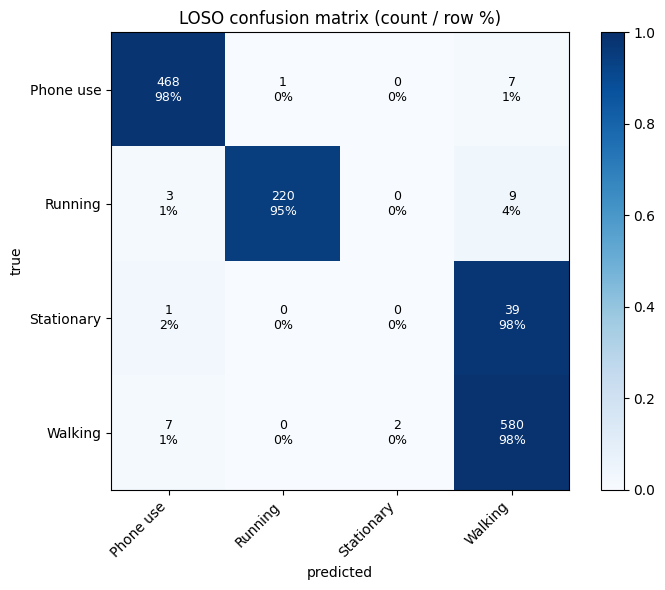

In [6]:
#6 — confusion matrix
import matplotlib.pyplot as plt

classes = sorted(np.unique(y))
cm = confusion_matrix(y_true_all, y_pred_all, labels=classes)
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(1.1*len(classes)+3, 1.0*len(classes)+2))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(classes)), classes, rotation=45, ha="right")
ax.set_yticks(range(len(classes)), classes)
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, f"{cm[i,j]}\n{cm_norm[i,j]:.0%}",
                ha="center", va="center", fontsize=9,
                color="white" if cm_norm[i,j] > 0.5 else "black")
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("LOSO confusion matrix (count / row %)")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

## Step 5 — Final model + what drives it
Trains on **all** sessions (deploy-ready) and shows which features matter — a good sanity check: locomotion classes should lean on `dom_freq`/`accmag_std`, not on `Acc*_mean` (which mostly encodes wrist orientation and can overfit to how you personally wear the nodes).

saved -> har_baseline_rf.joblib


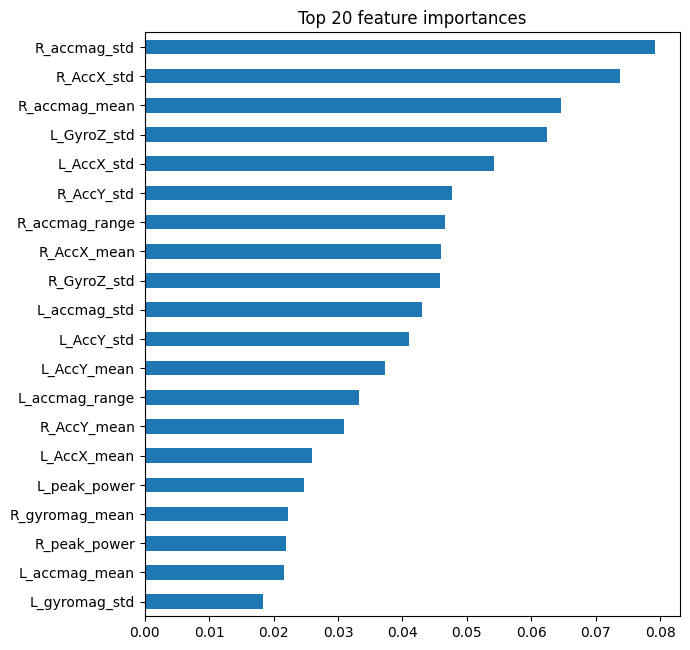

In [7]:
#7 — final model + feature importances
import joblib

clf_final = RandomForestClassifier(
    n_estimators=300, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1)
clf_final.fit(X, y)
joblib.dump({"model": clf_final, "features": feature_cols,
             "classes": sorted(np.unique(y))}, "har_baseline_rf.joblib")
print("saved -> har_baseline_rf.joblib")

imp = pd.Series(clf_final.feature_importances_, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(7, 0.28*min(20, len(imp)) + 1))
imp.tail(20).plot.barh(ax=ax)
ax.set_title("Top 20 feature importances"); plt.tight_layout(); plt.show()

In [8]:
# === EXPORT CELL — add to the END of HAR_Training.ipynb and run after cell #7 ===
# Retrains a compact forest (fewer/shallower trees -> small JSON asset) on ALL data
# and exports it for the Flutter app. Full-size model quality is nearly preserved;
# the size drop is what makes it a sane mobile asset.

import json
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

deploy = RandomForestClassifier(
    n_estimators=60, max_depth=12, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1)
deploy.fit(X, y)
print(f"compact model träin-set agreement with full model: "
      f"{accuracy_score(clf_final.predict(X), deploy.predict(X)):.1%}")

def tree_to_dict(t):
    tt = t.tree_
    return {
        "left":      tt.children_left.tolist(),
        "right":     tt.children_right.tolist(),
        "feature":   tt.feature.tolist(),
        "threshold": tt.threshold.tolist(),
        # class-count leaves -> normalized probabilities
        "value":     (tt.value[:, 0, :] /
                      tt.value[:, 0, :].sum(axis=1, keepdims=True).clip(min=1)).tolist(),
    }

bundle = {
    "classes": deploy.classes_.tolist(),
    "feature_names": feature_cols,          # exact order the Dart side must produce
    "trees": [tree_to_dict(t) for t in deploy.estimators_],
}

out_path = "/content/drive/MyDrive/HAR_data/har_model.json"
with open(out_path, "w") as f:
    json.dump(bundle, f)
import os
print(f"exported {out_path}  ({os.path.getsize(out_path)/1e6:.1f} MB, "
      f"{len(bundle['trees'])} trees, {len(feature_cols)} features, "
      f"classes: {bundle['classes']})")


compact model träin-set agreement with full model: 100.0%
exported /content/drive/MyDrive/HAR_data/har_model.json  (0.3 MB, 60 trees, 39 features, classes: ['Phone use', 'Running', 'Stationary', 'Walking'])


## Reading the results
- **Per-session accuracies vary a lot?** Normal with few sessions; the pooled number is the one to quote, and more sessions is the cure.
- **A class with poor recall?** Check the confusion matrix for *who* it's confused with, then decide: more recordings of it, a merged class, or (if it's context-defined like transport) accept that wrist IMUs may not carry the signal.
- **`Acc*_mean` features dominating importances?** The model may be keying on sensor orientation rather than motion — expect worse generalization to re-strapped sensors or other wearers.